In [22]:
import torch
from torchvision import transforms
import pandas as pd
import matplotlib.pyplot as plt


import zipfile
from pathlib import Path
from PIL import Image
import shutil
from tqdm.auto import tqdm
import random

import ml_modules

## Device Agnostic code

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

# Data preparation

## Unzip data

In [3]:
with zipfile.ZipFile('aptos2019-blindness-detection.zip', 'r') as zip_ref:

    zip_ref.extractall('dataset/aptos2019')

## Load data

### Data dir

In [4]:
dataset_dir = Path('dataset/aptos2019')

train_dir = dataset_dir / 'train_images'
train_labels_file = dataset_dir / 'train.csv'

test_dir = dataset_dir / 'test_images'

### Create class folders and move data

In [5]:
images = list(train_dir.glob('*.png'))
images[:5]

[WindowsPath('dataset/aptos2019/train_images/000c1434d8d7.png'),
 WindowsPath('dataset/aptos2019/train_images/001639a390f0.png'),
 WindowsPath('dataset/aptos2019/train_images/0024cdab0c1e.png'),
 WindowsPath('dataset/aptos2019/train_images/002c21358ce6.png'),
 WindowsPath('dataset/aptos2019/train_images/005b95c28852.png')]

### Visualize image

(np.float64(-0.5), np.float64(1049.5), np.float64(1049.5), np.float64(-0.5))

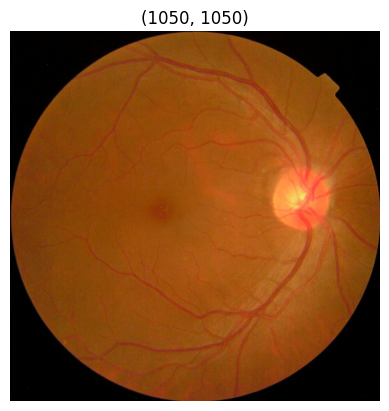

In [6]:
random_index = random.randint(0, len(images))
image = Image.open(images[random_index])
plt.title(label=image.size)
plt.imshow(image)
plt.axis(False)

### load labels

In [7]:
labels = pd.read_csv(train_labels_file)
labels.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


#### Split train data into train and validation set 

In [8]:
data_size = len(images)
train_size = (data_size*90//100)

train_images = images[:train_size]
validation_images = images[train_size:]

data_size, len(train_images), len(validation_images), train_images[:1], validation_images[:1]

(3662,
 3295,
 367,
 [WindowsPath('dataset/aptos2019/train_images/000c1434d8d7.png')],
 [WindowsPath('dataset/aptos2019/train_images/e4d3d437b0a8.png')])

#### Split labels

In [9]:
train_labels = labels[:train_size]
validation_labels = labels[train_size:]

len(train_labels), len(validation_labels), train_labels[:1], validation_labels[:1]

(3295,
 367,
         id_code  diagnosis
 0  000c1434d8d7          2,
            id_code  diagnosis
 3295  e4d3d437b0a8          0)

#### Saving train and validation images

In [10]:
def create_folders(dataset_dir: Path,
                   train_dir:bool,
                   test_dir:bool,
                   validatio_dir:bool,
                   classes: list[str] = ['']
                   ):

    train = Path('train')
    test = Path('test')
    validation = Path('validation')

    if train_dir:

        train = dataset_dir / train
        train.mkdir(parents=True, exist_ok=True)

    if test_dir:

        test = dataset_dir / test
        test.mkdir(parents=True, exist_ok=True)

    if validatio_dir:

        validation = dataset_dir / validation
        validation.mkdir(parents=True, exist_ok=True)


    for class_path in classes:


        if train_dir:

            train_class_path = train / class_path
            train_class_path.mkdir(exist_ok=True)

        if test_dir:

            test_class_path = test / class_path
            test_class_path.mkdir(exist_ok=True)

        if validatio_dir:

            validation_class_path = validation / class_path
            validation_class_path.mkdir(exist_ok=True)

    return train, test, validation

In [11]:
def copy_file(source_path, destination_path, file_name):

    try:

        shutil.copy2(source_path, destination_path / file_name)
    except:

        print(f"cannot copy {file_name} from {source_path} to {destination_path}")

In [12]:
## Create folders

classes = ['0', '1', '2', '3', '4']

train_dir, _, validation_dir = create_folders(dataset_dir=dataset_dir,
                                            train_dir=True,
                                            test_dir=False,
                                            validatio_dir=True,
                                            classes=classes)

print(f"[INFO] Folders created")

## For train images

print(f"[INFO] Saving training images")

for i in range(len(train_images)):

    train_image_path = train_images[i]
    train_image_name = train_image_path.parts[-1]

    train_label = str(train_labels['diagnosis'][i])

    copy_file(source_path=train_image_path,
              destination_path=train_dir / train_label,
              file_name=train_image_name)

print(f"[INFO] Train images saved at {train_dir}")


## For validation images

print(f"[INFO] Saving validation images")

for i in range(len(validation_images)):

    validation_image_path = validation_images[i]
    validation_image_name = validation_image_path.parts[-1]

    validation_label = str(list(validation_labels['diagnosis'])[i])

    copy_file(source_path=validation_image_path,
              destination_path=validation_dir / validation_label,
              file_name=validation_image_name)

print(f"[INFO] Validation images saved at {validation_dir}")

[INFO] Folders created
[INFO] Saving training images
[INFO] Train images saved at dataset\aptos2019\train
[INFO] Saving validation images
[INFO] Validation images saved at dataset\aptos2019\validation


### Create dataloaders

In [13]:
manual_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

BATCH_SIZE = 32
NUM_WORKERS = 0
 
train_dataloader, vlaidation_dataloader, classes =  ml_modules.get_dataloaders(train_dir=train_dir,
                                                                         test_dir=validation_dir,
                                                                         BATCH_SIZE=BATCH_SIZE,
                                                                         NUM_WORKERS=NUM_WORKERS,
                                                                         train_transform=manual_transform,
                                                                         test_transform=manual_transform)

In [14]:
classes

['0', '1', '2', '3', '4']

In [15]:
images = vlaidation_dataloader

In [21]:
len(images) * 32

384

In [ ]:
import ml_modules
import torchvision

In [18]:
weights_1 = torchvision.models.EfficientNet_B2_Weights.DEFAULT
weights_2 = torchvision.models.ResNet101_Weights.DEFAULT

In [19]:
weights_1.transforms(), weights_2.transforms()

(ImageClassification(
     crop_size=[288]
     resize_size=[288]
     mean=[0.485, 0.456, 0.406]
     std=[0.229, 0.224, 0.225]
     interpolation=InterpolationMode.BICUBIC
 ),
 ImageClassification(
     crop_size=[224]
     resize_size=[232]
     mean=[0.485, 0.456, 0.406]
     std=[0.229, 0.224, 0.225]
     interpolation=InterpolationMode.BILINEAR
 ))

In [1]:
import torchvision

weights = torchvision.models.ViT_B_16_Weights.DEFAULT

weights.transforms()

vit_mode = torchvision.models.vit_b_16(weights)


c:\miniconda3\envs\ml-base\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


In [2]:
import ml_modules

ml_modules.model_summary(model=vit_mode,
                         input_size=[32, 3, 224, 224])

D:\Work\Coding\Machine-Learning\ml_modules\ml_modules\engine.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


Layer (type (var_name))                                      Param #              Input Shape          Output Shape         Trainable
VisionTransformer (VisionTransformer)                        768                  [32, 3, 224, 224]    [32, 1000]           True
├─Conv2d (conv_proj)                                         590,592              [32, 3, 224, 224]    [32, 768, 14, 14]    True
├─Encoder (encoder)                                          151,296              [32, 197, 768]       [32, 197, 768]       True
│    └─Dropout (dropout)                                     --                   [32, 197, 768]       [32, 197, 768]       --
│    └─Sequential (layers)                                   --                   [32, 197, 768]       [32, 197, 768]       True
│    │    └─EncoderBlock (encoder_layer_0)                   7,087,872            [32, 197, 768]       [32, 197, 768]       True
│    │    └─EncoderBlock (encoder_layer_1)                   7,087,872            [32, 197, 76

In [3]:
for params in vit_mode.parameters():

    params.requires_grad = False

In [4]:

ml_modules.model_summary(model=vit_mode,
                         input_size=[32, 3, 224, 224])

Layer (type (var_name))                                      Param #              Input Shape          Output Shape         Trainable
VisionTransformer (VisionTransformer)                        768                  [32, 3, 224, 224]    [32, 1000]           False
├─Conv2d (conv_proj)                                         (590,592)            [32, 3, 224, 224]    [32, 768, 14, 14]    False
├─Encoder (encoder)                                          151,296              [32, 197, 768]       [32, 197, 768]       False
│    └─Dropout (dropout)                                     --                   [32, 197, 768]       [32, 197, 768]       --
│    └─Sequential (layers)                                   --                   [32, 197, 768]       [32, 197, 768]       False
│    │    └─EncoderBlock (encoder_layer_0)                   (7,087,872)          [32, 197, 768]       [32, 197, 768]       False
│    │    └─EncoderBlock (encoder_layer_1)                   (7,087,872)          [32, 19

In [5]:
vit_mode

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [7]:
from torch import nn

vit_mode.heads = nn.Sequential(
    nn.Linear(in_features=768,
              out_features=4,
              bias=True)
)

In [8]:

ml_modules.model_summary(model=vit_mode,
                         input_size=[32, 3, 224, 224])

Layer (type (var_name))                                      Param #              Input Shape          Output Shape         Trainable
VisionTransformer (VisionTransformer)                        768                  [32, 3, 224, 224]    [32, 4]              Partial
├─Conv2d (conv_proj)                                         (590,592)            [32, 3, 224, 224]    [32, 768, 14, 14]    False
├─Encoder (encoder)                                          151,296              [32, 197, 768]       [32, 197, 768]       False
│    └─Dropout (dropout)                                     --                   [32, 197, 768]       [32, 197, 768]       --
│    └─Sequential (layers)                                   --                   [32, 197, 768]       [32, 197, 768]       False
│    │    └─EncoderBlock (encoder_layer_0)                   (7,087,872)          [32, 197, 768]       [32, 197, 768]       False
│    │    └─EncoderBlock (encoder_layer_1)                   (7,087,872)          [32, 